
### [ 주제 : 사과 & 바나나 분류 - (3) 학습 및 평가 ]
**[1] 학습 종류와 학습 방법/모델**
- **[2] 모델 평가**

**학습 종류와 학습 방법/모델**
* 학습 종류 : 지도학습 - 분류
* 학습 방법/모델 : 분류 모델들 중 선택

- **학습/모델 평가**
* 학습에 사용되지 않은 데이터로 평가 == > 테스트 데이터셋

In [3]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")

import importlib
import cv_utils

importlib.reload(cv_utils)

from sklearn.model_selection import train_test_split #학습용| 테스트용 데이터 분할
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier # 모델클래스
from sklearn.metrics import accuracy_score, classification_report #평가

**[0] 사전준비**
- 모듈로딩
- 폴더 체크 및 생성

In [4]:

## --------------------------------------------------
## 데이터 준비
## --------------------------------------------------

## 데이터 파일
DATA_FILE = './fruit_data.csv'

## (1) 데이터 로딩
df = pd.read_csv(DATA_FILE)

## (2) 기본정보 확인
df.info()
display(df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Columns: 50178 entries, filename to label
dtypes: int64(50176), object(2)
memory usage: 110.3+ MB


,filename,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel50167,pixel50168,pixel50169,pixel50170,pixel50171,pixel50172,pixel50173,pixel50174,pixel50175,label
0,apple_0000_crop.jpg,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,apple
1,apple_0001_crop.jpg,255,255,255,254,245,244,244,244,244,...,244,244,244,244,245,254,255,255,255,apple
2,apple_0002_crop.jpg,255,255,255,255,255,255,255,255,255,...,254,255,255,255,255,255,255,255,255,apple


**[2] 데이터와 타겟/라벨 분리**

In [8]:

## --------------------------------------------------
## => 학습 데이터와 정답지 타겟 분리
## --------------------------------------------------
## X : pixel0 ~ pixel50175
## y : apple / banana

# filename과 label 컬럼을 제외한 픽셀 데이터
X = df.drop(
    columns=["filename", "label"]
).values

# 정답 라벨
y = df["label"].values

print()
print("분리 후")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("정규화 전 최솟값:", X.min())
print("정규화 전 최댓값:", X.max())


## --------------------------------------------------
## => 숫자 학습 데이터 연산
## --------------------------------------------------
## 데이터 정규화: 0~255 → 0~1

X = X.astype(np.float32)
X = X / 255.0

print()
print("정규화 후")
print("X 최솟값:", X.min())
print("X 최댓값:", X.max())


## --------------------------------------------------
## => 학습용 / 테스트용 데이터 분리
## --------------------------------------------------
## 학습용 80%, 테스트용 20%

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## --------------------------------------------------
## => 데이터 분리 결과 확인
## --------------------------------------------------

print()
print("데이터 분리 후")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print()
print("학습용 라벨 개수")
print(pd.Series(y_train).value_counts())

print()
print("테스트용 라벨 개수")
print(pd.Series(y_test).value_counts())


분리 후
X shape: (288, 50176)
y shape: (288,)
정규화 전 최솟값: 0
정규화 전 최댓값: 255

정규화 후
X 최솟값: 0.0
X 최댓값: 1.0

데이터 분리 후
X_train: (230, 50176)
X_test : (58, 50176)
y_train: (230,)
y_test : (58,)

학습용 라벨 개수
apple     150
banana     80
Name: count, dtype: int64

테스트용 라벨 개수
apple     38
banana    20
Name: count, dtype: int64


### [3] 학습용 & 테스트용 데이터셋 분리
- 학습용 데이터셋 => 일부를 테스트 데이터셋 사용
- 함수: train_test_split()
- 전체 학습용 데이터셋에 몇 %로 할지 설정 [기] 학습용 : 테스트용 = 75% : 25%
- 데이터를 섞어 주는 작업
- 불균형 데이터셋에 대한 설정 가능

In [11]:
## --------------------------------------------------
## => 학습용 / 테스트용 데이터 분리 (80% : 20%)
## => 데이터 : 2D
## => 라_벨 : 1D
## => 재현성 : random_state=숫자 데이터셋을 섞지만, 매번 동일하게
## => 균형: 
## --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

print(f'train : {X_train.shape}, test : {X_test. shape}')

train : (230, 50176), test : (58, 50176)


In [14]:
## --------------------------------------------------
## =>모델 생성 및 학습
## --------------------------------------------------
## ==> 모델 인스턴스 생성
kModel = KNeighborsClassifier()
svcModel= SVC(kernel='linear')

## => 학습 fit(2D, 1D)
kModel.fit(X_train, y_train)
svcModel.fit(X_train, y_train)

SVC(kernel='linear')

**[5] 평가**
- 학습용 데이터=> 점수
- 테스트용 데이터=> 점수
- 메서드: score(2D 데이터, 1D 정답)

In [15]:
## 학습용 데이터셋 점수
train_score_KNN= kModel.score(X_train, y_train)
train_score_SVC= svcModel.score(X_train, y_train)

## 테스트용 데이터셋 점수
test_score_KNN= kModel.score(X_test, y_test)
test_score_SVC= svcModel.score(X_test, y_test)

## 비교
print(f"KNN [TRAIN] {train_score_KNN}점 [TEST]{test_score_KNN}점")
print(f"SvC [TRAIN] {train_score_SVC}점 [TEST] {test_score_SVC}점")




c:\Users\KDT30\anaconda3\envs\hanicv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


KNN [TRAIN] 0.9434782608695652점 [TEST]0.9310344827586207점
SvC [TRAIN] 1.0점 [TEST] 0.8448275862068966점


In [17]:
## -------------------------------------------
## 기존 데이터 활용한 예측
## -------------------------------------------


## => 테스트 데이터 1개 선택 : 1D => 2D
data = X_test[0].reshape(1, -1)

## => 예측
pre_y = kModel.predict(data)

print(f"예측: {pre_y[0]} 정답 : {y_test[0]}")

예측: apple 정답 : apple


In [32]:
## -------------------------------------------
## 새로 수집한 데이터 활용 예측
## -------------------------------------------

# 학습 시 사용한 데이터셋 형태로 변환
# -> 사이즈 100*100
# -> 그레이스케일
# 픽셀값: 0~255 ==> 0~1 로 정규화

## -------------------------------------------
#  함수기능: 새로운 데이터를 학습용 데이터로 변환 처리
#  함수이름: covert_data
#  매개변수: filepath 파일 경로+ 파일명
#  반환결과: 학습용 데이터 형태 ndarray
## -------------------------------------------

def convert_data(filepath):

    import cv2

    # (1) 이미지 데이터 로딩+ 흑백

    imgNP= cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

    # (2) 크기 조절: 비율 유지 50%+ 절대 크기 100*100

    imgNP= cv2.resize(imgNP, (0, 0), fx= 0.5, fy= 0.5)
    re_imgNP= cv2.resize(imgNP, (224, 224))

    # (3) 픽셀 정규화: 0~ 255 ==> 0~1
    re_imgNP= re_imgNP/255.
    print(f're_imgNP : max - {re_imgNP.max()}, min - { re_imgNP.min()}')

    return re_imgNP.flatten()
    

re_imgNP : max - 0.788235294117647, min - 0.08627450980392157
[결과] 예측: apple 정답 : apple.png


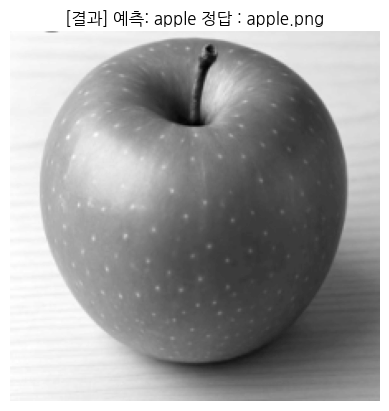

In [48]:
from pathlib import Path

new_data= convert_data("./Images/apple.png").reshape(1, -1)
new_label= "./Images/apple.png".split("/")[2]


pre_y=kModel.predict(new_data)
print(f"[결과] 예측: {pre_y[0]} 정답 : {new_label}")

plt.imshow(new_data.reshape(224, 224), cmap='gray')
plt.title(f"[결과] 예측: {pre_y[0]} 정답 : {new_label}")
plt.axis('off')
plt.show()

In [64]:
new_files = [ "./Images/apple.png", "./Images/banana.png"]

# filepath에 apple.png, banana.png가 하나씩 들어감
new_data = [ convert_data(filepath).reshape(1, -1) for filepath in new_files]

# (1, 50176) 두 개를 (2, 50176)으로 합침
new_data = np.vstack(new_data)

# 파일명에서 정답 라벨 추출
new_label = [ Path(filepath).stem for filepath in new_files]

# 두 장 동시에 예측
pre_y = kModel.predict(new_data)

print("new_data 크기:", new_data.shape)

for filepath, pred, label in zip( new_files, pre_y, new_label):
    print( f"[결과] 파일: {filepath} / " f"예측: {pred} / 정답: {label}")


re_imgNP : max - 0.788235294117647, min - 0.08627450980392157
re_imgNP : max - 0.9686274509803922, min - 0.13725490196078433
new_data 크기: (2, 50176)
[결과] 파일: ./Images/apple.png / 예측: apple / 정답: apple
[결과] 파일: ./Images/banana.png / 예측: banana / 정답: banana


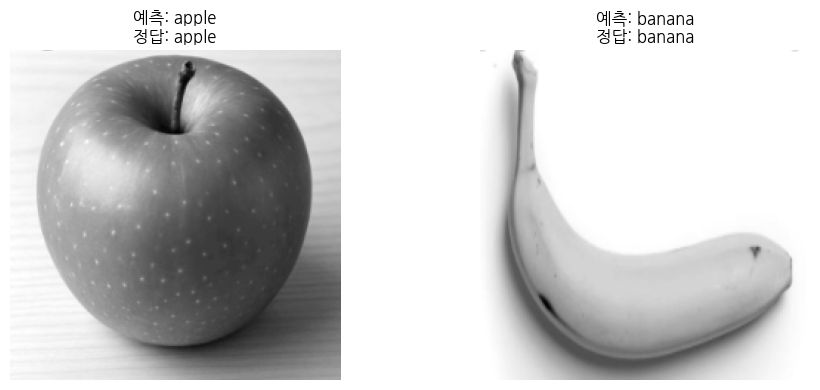

In [67]:
fig, axes = plt.subplots( 1, len(new_files), figsize=(10, 4))
axes = np.atleast_1d(axes)

for ax, data, pred, label in zip( axes, new_data, pre_y, new_label):
    ax.imshow( data.reshape(224, 224), cmap="gray")
    ax.set_title( f"예측: {pred}\n정답: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
class knnMD